In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom

from pylinac import FieldProfileAnalysis, Centering, Normalization, Edge
from pylinac.metrics.profile import (
    PenumbraLeftMetric,
    PenumbraRightMetric,
    SymmetryAreaMetric,
    FlatnessDifferenceMetric,
)

from FauxPID.algorithms.metrics import FlatnessCalculationByVariance

This notebook is used for testing metrics and analyzing DCM images. There's a bunch of random stuff. 

pylinac_version: 3.44.0
date_of_analysis: 2026-08-06T15:39:09.584213
warnings: []
x_metrics:
Left Penumbra (mm): 10.07015544067633
Right Penumbra (mm): 10.070154479000504
Symmetry (Area): -6.709458313475831e-15
Flatness (Difference) (%): 2.110208038177612
Field Width (mm): 100.12999385735208
y_metrics:
Left Penumbra (mm): 10.07297574958158
Right Penumbra (mm): 10.072979196516352
Symmetry (Area): 0.0
Flatness (Difference) (%): 2.1102080381776185
Field Width (mm): 100.12675299744934
center:
mean: 59204.0
stdev: 0.0
min: 59204.0
max: 59204.0
normalization: Beam center
edge_type: Inflection Derivative
centering: Beam center



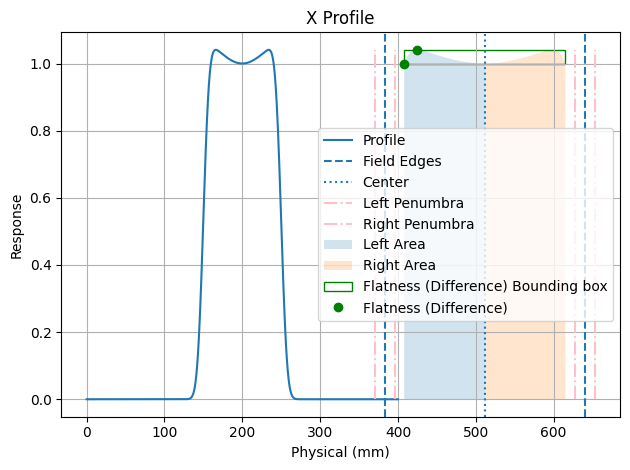

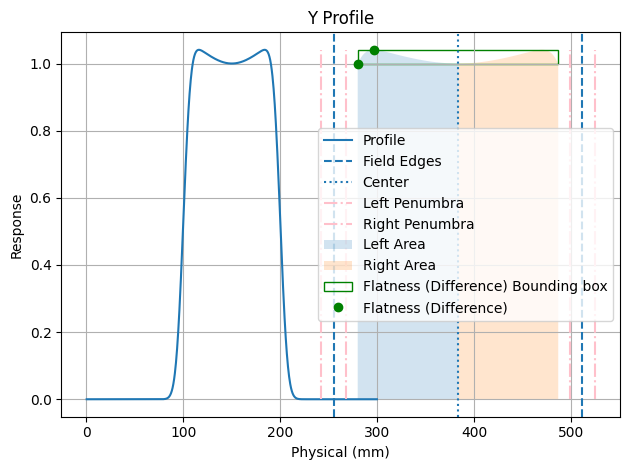

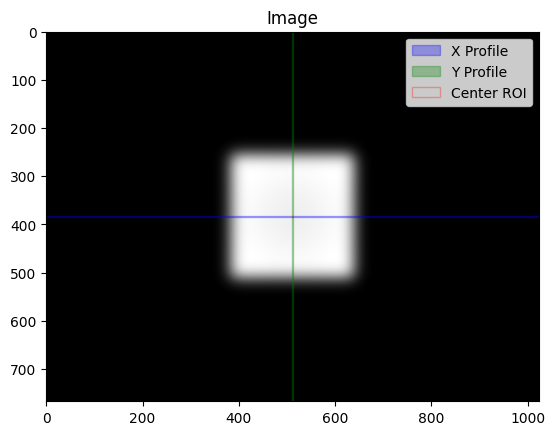

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

In [30]:
path = 'test_images/penumbra_excess.dcm'
field_analyzer = FieldProfileAnalysis(path)
field_analyzer.analyze(
    centering=Centering.BEAM_CENTER,
    # x_width=0.02,
    # y_width=0.02,
    normalization=Normalization.BEAM_CENTER,
    edge_type=Edge.INFLECTION_DERIVATIVE,
    ground=True,
    metrics=(
        PenumbraLeftMetric(),
        PenumbraRightMetric(),
        SymmetryAreaMetric(),
        FlatnessDifferenceMetric(),
    ),
)
print(field_analyzer.results())
field_analyzer.plot_analyzed_images()


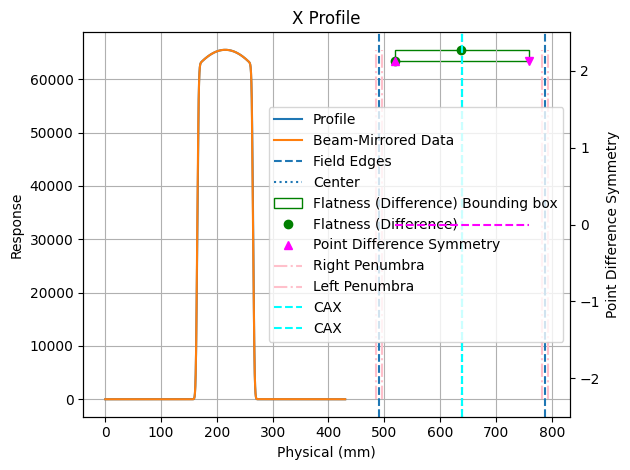

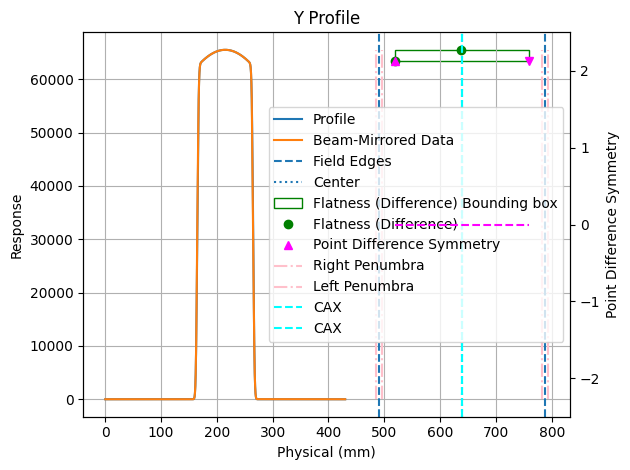

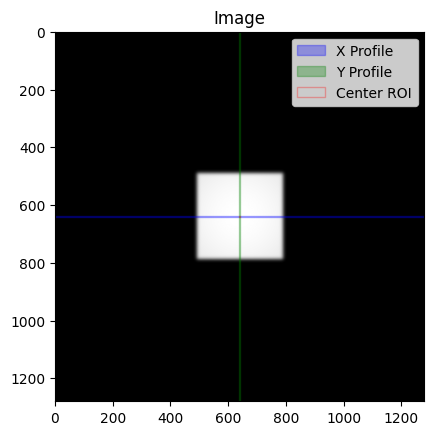

[<Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 1 Axes>]

In [4]:
path = 'EPID_Jaw 10x10.dcm'
field_analyzer = FieldProfileAnalysis(path)
field_analyzer.analyze()
field_analyzer.plot_analyzed_images(show_grid=True, mirror="beam")